# CTEPH AGP3K v6 — rare-variant pre-check QC

Depth-aware quality control for the fixed-model `maf_lt_threshold` call set
(`…/wgs.auto.par/results/14_fixed_model_prep/refined_core/`).

**Pipeline**

| Step | Purpose | Output |
| :--- | :--- | :--- |
| **0 · CALC_METRICS** | Run (or reuse cached) PLINK2 sample/variant metrics, incl. depth-stratified missingness `VMISS`, `VMISS_15X`, `VMISS_30X`. | `results/00_minac0/` |
| **1 · Sample QC** | Depth-adjusted minor-allele burden — `SMinAC` residual vs `MeanDP` (robust Theil–Sen fit); flag & export robust-z outlier **samples**. | `results/01_resid_outliers_z*/` |
| **2 · Variant QC** | Distribution of the 30X−15X missing-rate difference; kneedle threshold on the \|Δ\| CDF. | (figure) |
| **3 · Export** | Variant IDs to **exclude** at the chosen knee threshold. | `results/02_vmiss_depthdiff_knee/` |

**Usage / requirements**

- **Kernel:** conda env **`cteph_geno_pro`** (provides the weighted `kneed` build used in step 2).
- **Step 0** caches the ~minutes-long PLINK2 run: it auto-skips when the outputs already exist *and* carry the `VMISS` columns. Set `FORCE_RECALC = True` once to rebuild, then back to `False`.
- Cells are run top-to-bottom; downstream cells depend on variables defined upstream (`sample_metrics_path`, `variant_metrics_path`, `knee_thr`, …).
- Exported sample/variant lists are PLINK2 `--remove` / `--exclude` compatible (no header).


## Step 0 · CALC_METRICS — sample & variant metrics

Builds (or reuses cached) `sample_metrics` and `variant_metrics` via `run_calc_metrics.sh` → `calc_metrics.py`. Defines `sample_metrics_path` / `variant_metrics_path` for all downstream cells.


In [1]:
from pathlib import Path
from datetime import datetime
import subprocess
import pandas as pd
from IPython.display import display

# CALC_METRICS pre-check (aligned with nf; fixed min_ac=0)
CONFIG = {
    'GTPath': '/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/wgs.auto.par/results',
    'InfoPath': '/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/info/cteph_agp3k.v6.20260507.xlsx',
    'ScriptDir': '/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tuning.rv/scripts',
    'Plink2': '/home/b/b37974/plink2_alpha6/plink2',
    'Tabix': '/home/b/b37974/htslib-1.9/tabix',
    'IDCol': 'ID_JHRPv6',
    'GroupCol': 'Outcome',
    'CaseValue': 'PH',
    'TdpCol': 'Target_Depth',
    'MdpCol': 'Observed_Depth',
    'ThreadsCalc': 4,
}

MIN_AC = 0
WORK_DIR = Path('/LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tuning.rv/pre_check/results/00_minac0')
WORK_DIR.mkdir(parents=True, exist_ok=True)

# Set True to force re-running CALC_METRICS even if outputs already exist.
FORCE_RECALC = False

# Variant-metric columns the downstream variant-QC cells depend on.
REQUIRED_VARIANT_COLS = ['VMISS', 'VMISS_15X', 'VMISS_30X']


def first_existing(paths):
    return next((p for p in paths if p.exists()), None)


def build_cmd(cfg: dict, min_ac: int):
    bed_prefix = (
        f"{cfg['GTPath']}/14_fixed_model_prep/refined_core/"
        'cteph_agp3k_v6_wgs_merged.sample_qc.variant_qc.popgmm.fixed_model.maf_lt_threshold'
    )
    return [
        'bash', f"{cfg['ScriptDir']}/run_calc_metrics.sh",
        '--bed-prefix', bed_prefix,
        '--info-file', cfg['InfoPath'],
        '--out-sample', 'sample_metrics.txt',
        '--out-variant', 'variant_metrics.txt',
        '--script-dir', cfg['ScriptDir'],
        '--plink2', cfg['Plink2'],
        '--tabix', cfg['Tabix'],
        '--id-col', cfg['IDCol'],
        '--group-col', cfg['GroupCol'],
        '--case-value', cfg['CaseValue'],
        '--tdp-col', cfg['TdpCol'],
        '--mdp-col', cfg['MdpCol'],
        '--min-ac', str(min_ac),
        '--threads', str(cfg['ThreadsCalc']),
    ]


def variant_cols(path):
    """Header columns of a (possibly gzipped) variant_metrics table; [] on failure."""
    if path is None:
        return []
    try:
        return list(pd.read_csv(path, sep='\t', nrows=0).columns)
    except Exception:
        return []


# Resolve output paths first, so downstream cells can connect whether or not we (re)run.
sample_metrics_path = first_existing([WORK_DIR / 'sample_metrics.txt.gz', WORK_DIR / 'sample_metrics.txt'])
variant_metrics_path = first_existing([WORK_DIR / 'variant_metrics.txt.gz', WORK_DIR / 'variant_metrics.txt'])
variant_tbi_path = WORK_DIR / 'variant_metrics.txt.gz.tbi'
log_path = WORK_DIR / 'calc_metrics.log'

# Cache check: skip the heavy run only if the key outputs exist AND already carry
# the required VMISS columns (a stale pre-VMISS file must be rebuilt).
_cached_cols = variant_cols(variant_metrics_path)
_cache_has_cols = all(c in _cached_cols for c in REQUIRED_VARIANT_COLS)
outputs_ready = (
    sample_metrics_path is not None
    and variant_metrics_path is not None
    and variant_tbi_path.exists()
    and _cache_has_cols
)

if outputs_ready and not FORCE_RECALC:
    run_status = 'cached'
    duration_sec = None
    print('CALC_METRICS outputs already exist (with VMISS cols) -> skipping run '
          '(set FORCE_RECALC=True to rebuild).')
else:
    if FORCE_RECALC:
        print('FORCE_RECALC=True -> running CALC_METRICS.')
    elif variant_metrics_path is not None and not _cache_has_cols:
        _miss = [c for c in REQUIRED_VARIANT_COLS if c not in _cached_cols]
        print(f'Cached variant_metrics is missing {_miss} -> rebuilding CALC_METRICS.')
    else:
        print('CALC_METRICS outputs missing/incomplete -> running.')

    cmd = build_cmd(CONFIG, MIN_AC)
    t0 = datetime.now()
    res = subprocess.run(cmd, cwd=WORK_DIR, capture_output=True, text=True)
    t1 = datetime.now()

    if res.returncode != 0:
        err_tail = '\n'.join(res.stderr.strip().splitlines()[-60:]) if res.stderr.strip() else '(no stderr)'
        raise RuntimeError(f'CALC_METRICS failed (code={res.returncode})\n--- stderr tail ---\n{err_tail}')

    run_status = 'success'
    duration_sec = round((t1 - t0).total_seconds(), 1)

    # Re-resolve paths now that outputs have been (re)written.
    sample_metrics_path = first_existing([WORK_DIR / 'sample_metrics.txt.gz', WORK_DIR / 'sample_metrics.txt'])
    variant_metrics_path = first_existing([WORK_DIR / 'variant_metrics.txt.gz', WORK_DIR / 'variant_metrics.txt'])

run_summary = pd.DataFrame([
    {'item': 'status', 'value': run_status},
    {'item': 'min_ac', 'value': MIN_AC},
    {'item': 'duration_sec', 'value': duration_sec},
    {'item': 'work_dir', 'value': str(WORK_DIR)},
])

file_rows = []
for label, path_obj in [
    ('sample_metrics', sample_metrics_path),
    ('variant_metrics', variant_metrics_path),
    ('variant_metrics_tbi', variant_tbi_path),
    ('calc_metrics_log', log_path),
]:
    exists = path_obj is not None and Path(path_obj).exists()
    size_mb = (Path(path_obj).stat().st_size / (1024 * 1024)) if exists else None
    file_rows.append({
        'file': label,
        'exists': bool(exists),
        'size_mb': round(size_mb, 3) if size_mb is not None else None,
        'path': str(path_obj) if path_obj is not None else 'NOT FOUND',
    })

file_check = pd.DataFrame(file_rows)

# Final sanity: confirm the produced variant_metrics carries the required columns.
_final_cols = variant_cols(variant_metrics_path)
_missing_final = [c for c in REQUIRED_VARIANT_COLS if c not in _final_cols]
if _missing_final:
    print(f'[warn] variant_metrics is missing {_missing_final}; '
          'the variant-QC cells will fail. Re-run with FORCE_RECALC=True.')

# Minimal output
print('CALC_METRICS pre-check finished.')
display(run_summary)
display(file_check)


CALC_METRICS outputs missing/incomplete -> running.
CALC_METRICS pre-check finished.


,item,value
0,status,success
1,min_ac,0
2,duration_sec,310.2
3,work_dir,/LARGE0/gr10478/b37974/Pulmonary_Hypertension/...


,file,exists,size_mb,path
0,sample_metrics,True,0.049,/LARGE0/gr10478/b37974/Pulmonary_Hypertension/...
1,variant_metrics,True,330.399,/LARGE0/gr10478/b37974/Pulmonary_Hypertension/...
2,variant_metrics_tbi,True,1.517,/LARGE0/gr10478/b37974/Pulmonary_Hypertension/...
3,calc_metrics_log,True,0.017,/LARGE0/gr10478/b37974/Pulmonary_Hypertension/...


## Step 1 · Sample QC — depth-adjusted minor-allele burden

Regresses `SMinAC` on `MeanDP` (robust Theil–Sen), then flags samples whose **residual** robust-z exceeds `ROBUST_Z_THRESHOLD`. Exports the outlier sample IDs (`FID<TAB>IID`, no header) to `results/01_resid_outliers_z{threshold}/`.


Robust fit (Theil-Sen): SMinAC = 117.6 * MeanDP + 2.934e+04
Residual robust z outliers (|z| > 5): 4
ID column used : SampleID
Outlier file   : /LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tuning.rv/pre_check/results/01_resid_outliers_z5/outliers_sminac_resid_robustz.remove.txt  (4 samples)


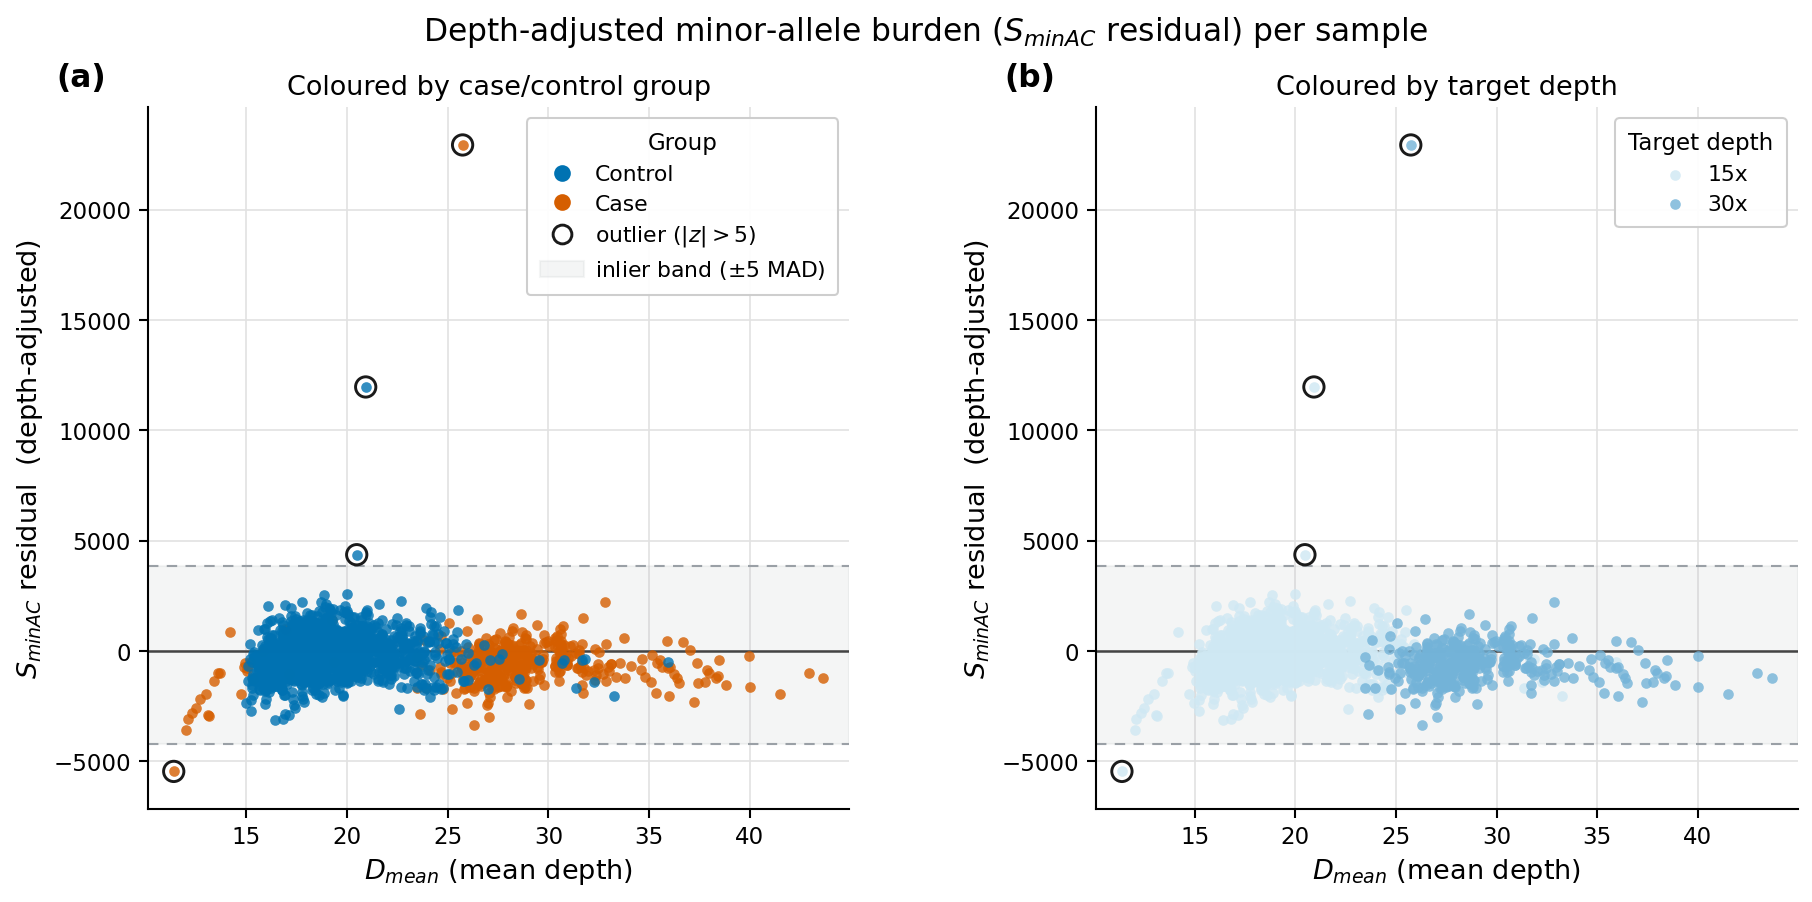

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

# =========================
# 1) Parameters
# =========================
ROBUST_Z_THRESHOLD = 5.0  # |robust z| cutoff for residual outlier marking
plt.style.use('default')

# Colorblind-safe palettes (Wong 2011)
GROUP_COLORS   = {'Case': '#D55E00', 'Control': '#0072B2', 'NaN': '#7F7F7F'}
GROUP_FALLBACK = ['#009E73', '#CC79A7', '#E69F00', '#56B4E9', '#F0E442']
TARGETDP_GRADIENT = ['#CFE8F3', '#73B3D8', '#2878B5', '#0F4C81']

# =========================
# 2) Load Data
# =========================
if 'sample_metrics_path' not in globals() or sample_metrics_path is None:
    _src = WORK_DIR / 'sample_metrics.txt.gz'
    if not _src.exists():
        raise FileNotFoundError('sample_metrics_path missing. Run Cell 1 first.')
else:
    _src = sample_metrics_path

df = pd.read_csv(_src, sep='\t')
required_cols = ['MeanDP', 'SMinAC', 'Group', 'TargetDP']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing columns: {missing_cols}')

# =========================
# 3) Regress SMinAC ~ MeanDP, take residual as the y metric
#    (robust Theil-Sen fit so outlier samples do not bias the line)
# =========================
df_plot = df.copy()
sminac_num = pd.to_numeric(df_plot['SMinAC'], errors='coerce')
meandp_num = pd.to_numeric(df_plot['MeanDP'], errors='coerce')

fit_mask = sminac_num.notna() & meandp_num.notna()
if fit_mask.sum() < 2:
    raise ValueError('Not enough finite (SMinAC, MeanDP) pairs to fit a regression.')

x_fit = meandp_num[fit_mask].to_numpy(dtype=float)
y_fit = sminac_num[fit_mask].to_numpy(dtype=float)
try:
    from scipy.stats import theilslopes
    slope, intercept = theilslopes(y_fit, x_fit)[:2]   # robust (median-based) fit
    fit_kind = 'Theil-Sen'
except Exception:
    slope, intercept = np.polyfit(x_fit, y_fit, 1)      # OLS fallback
    fit_kind = 'OLS'

# Residual = observed SMinAC - depth-predicted SMinAC
df_plot['SMinAC_resid'] = sminac_num - (slope * meandp_num + intercept)

# =========================
# 3b) Robust-z on the residual -> outlier flag
# =========================
resid_num = df_plot['SMinAC_resid']
median_r = float(np.nanmedian(resid_num))
mad_r    = float(np.nanmedian(np.abs(resid_num - median_r)))
if np.isnan(mad_r) or mad_r == 0:
    df_plot['resid_robust_z_abs'] = np.nan
else:
    df_plot['resid_robust_z_abs'] = np.abs(0.6745 * (resid_num - median_r) / mad_r)

df_plot['resid_is_outlier'] = df_plot['resid_robust_z_abs'] > ROBUST_Z_THRESHOLD
outlier_df = df_plot[df_plot['resid_is_outlier']]
print(f'Robust fit ({fit_kind}): SMinAC = {slope:.4g} * MeanDP + {intercept:.4g}')
print(f'Residual robust z outliers (|z| > {ROBUST_Z_THRESHOLD:g}): {len(outlier_df)}')

# =========================
# 3c) Export outliers as  FID<TAB>IID  (FID == IID, no header)
# =========================
id_col = next((c for c in ('SampleID', 'IID', 'ID') if c in df_plot.columns), df_plot.columns[0])
OUT_DIR_01 = WORK_DIR.parent / f'01_resid_outliers_z{ROBUST_Z_THRESHOLD:g}'
OUT_DIR_01.mkdir(parents=True, exist_ok=True)
OUTLIER_FILE = OUT_DIR_01 / 'outliers_sminac_resid_robustz.remove.txt'

outlier_ids = outlier_df[id_col].astype(str)
with open(OUTLIER_FILE, 'w') as f:
    for sid in outlier_ids:
        f.write(f'{sid}\t{sid}\n')
print(f'ID column used : {id_col}')
print(f'Outlier file   : {OUTLIER_FILE}  ({len(outlier_ids)} samples)')

# =========================
# 4) Color Maps
# =========================
# Group
group_color_map, _fb = {}, 0
for g in df_plot['Group'].fillna('NaN').astype(str).unique():
    if g in GROUP_COLORS:
        group_color_map[g] = GROUP_COLORS[g]
    else:
        group_color_map[g] = GROUP_FALLBACK[_fb % len(GROUP_FALLBACK)]
        _fb += 1

# TargetDP: numeric → colorbar; categorical → discrete legend
targetdp_is_numeric = pd.api.types.is_numeric_dtype(df_plot['TargetDP'])
if not targetdp_is_numeric:
    levels = list(df_plot['TargetDP'].fillna('NaN').astype(str).unique())
    sort_key = pd.Series(levels).str.extract(r'(\d+(?:\.\d+)?)', expand=False).astype(float)
    sort_df = pd.DataFrame({'level': levels, 'num': sort_key})
    sort_df['_na'] = sort_df['num'].isna()
    levels_sorted = sort_df.sort_values(['_na', 'num', 'level'])['level'].tolist()
    targetdp_color_map = {
        t: ('#7F7F7F' if t == 'NaN' else TARGETDP_GRADIENT[i % len(TARGETDP_GRADIENT)])
        for i, t in enumerate(levels_sorted)
    }

# =========================
# 5) Publication-grade plot style
# =========================
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'savefig.dpi': 600, 'savefig.bbox': 'tight', 'figure.dpi': 150,
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 10.5, 'legend.title_fontsize': 11,
    'axes.linewidth': 1.0, 'mathtext.fontset': 'dejavusans',
})

SCATTER_KW = dict(s=26, alpha=0.80, linewidths=0.0, zorder=3)
OUTLIER_KW = dict(s=95, facecolors='none', edgecolors='#1A1A1A', linewidths=1.4, zorder=6)
x_lbl = r'$\mathit{D}_{\mathit{mean}}$ (mean depth)'
y_lbl = r'$\mathit{S}_{\mathit{minAC}}$ residual  (depth-adjusted)'
y_col = 'SMinAC_resid'

# Shared, comparable axis limits.
_x = meandp_num[np.isfinite(meandp_num)]
_y = resid_num[np.isfinite(resid_num)]
x_pad, y_pad = 0.04 * (_x.max() - _x.min()), 0.06 * (_y.max() - _y.min())
XLIM = (_x.min() - x_pad, _x.max() + x_pad)
YLIM = (_y.min() - y_pad, _y.max() + y_pad)

# Residual cutoff implied by the robust-z threshold (for the inlier band).
band = (ROBUST_Z_THRESHOLD * mad_r / 0.6745) if (mad_r and not np.isnan(mad_r)) else np.nan
lo, hi = median_r - band, median_r + band

# =========================
# 6) Figure
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.9), constrained_layout=True)

def _frame(ax):
    ax.set_box_aspect(1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4.5, width=1.0)
    ax.set_axisbelow(True)
    ax.grid(True, which='major', color='#E2E2E2', linewidth=0.8, zorder=0)
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    # Inlier band (|robust z| <= threshold) + zero baseline
    if np.isfinite(band):
        ax.axhspan(lo, hi, color='#9AA0A6', alpha=0.10, zorder=1)
        ax.axhline(lo, color='#9AA0A6', linestyle=(0, (5, 4)), linewidth=1.0, zorder=2)
        ax.axhline(hi, color='#9AA0A6', linestyle=(0, (5, 4)), linewidth=1.0, zorder=2)
    ax.axhline(0.0, color='#444444', linewidth=1.2, zorder=2)
    ax.set_xlabel(x_lbl)

# --- (a) coloured by Group ---
ax = axes[0]
_frame(ax)
for gname, sub in df_plot.groupby('Group', dropna=False):
    lbl = str(gname) if pd.notna(gname) else 'NaN'
    ax.scatter(sub['MeanDP'], sub[y_col], color=group_color_map[lbl], label=lbl, **SCATTER_KW)
if not outlier_df.empty:
    ax.scatter(outlier_df['MeanDP'], outlier_df[y_col], **OUTLIER_KW)
ax.set_ylabel(y_lbl)
ax.set_title('Coloured by case/control group')

_handles = [Line2D([0], [0], marker='o', linestyle='', color=group_color_map[g],
                   markersize=7, label=g) for g in group_color_map]
_handles.append(Line2D([0], [0], marker='o', linestyle='', markerfacecolor='none',
                       markeredgecolor='#1A1A1A', markeredgewidth=1.4, markersize=9,
                       label=fr'outlier ($|z|>{ROBUST_Z_THRESHOLD:g}$)'))
_handles.append(Patch(facecolor='#9AA0A6', alpha=0.10, edgecolor='#9AA0A6',
                      label=fr'inlier band ($\pm{ROBUST_Z_THRESHOLD:g}$ MAD)'))
ax.legend(handles=_handles, title='Group', loc='upper right', frameon=True,
          framealpha=0.95, borderpad=0.6, handletextpad=0.5, labelspacing=0.45)

# --- (b) coloured by TargetDP ---
ax = axes[1]
_frame(ax)
if targetdp_is_numeric:
    sc = ax.scatter(df_plot['MeanDP'], df_plot[y_col], c=df_plot['TargetDP'],
                    cmap='viridis', **SCATTER_KW)
    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label('Target depth', fontsize=11)
    cbar.ax.tick_params(labelsize=10, length=3, width=0.8)
    cbar.outline.set_linewidth(0.8)
else:
    for tname, sub in df_plot.groupby('TargetDP', dropna=False):
        lbl = str(tname) if pd.notna(tname) else 'NaN'
        ax.scatter(sub['MeanDP'], sub[y_col], color=targetdp_color_map[lbl], label=lbl, **SCATTER_KW)
    ax.legend(title='Target depth', loc='upper right', frameon=True, framealpha=0.95,
              borderpad=0.6, handletextpad=0.5, labelspacing=0.45)
if not outlier_df.empty:
    ax.scatter(outlier_df['MeanDP'], outlier_df[y_col], **OUTLIER_KW)
ax.set_ylabel(y_lbl)
ax.set_title('Coloured by target depth')

# Suptitle (constrained_layout reserves room); panel letters pinned to the far-left
# corner of each axes so they never collide with the centred suptitle.
fig.suptitle(r'Depth-adjusted minor-allele burden ($\mathit{S}_{\mathit{minAC}}$ residual) per sample',
             fontsize=15)
for ax, letter in zip(axes, 'ab'):
    ax.text(-0.13, 1.02, f'({letter})', transform=ax.transAxes,
            fontsize=15, fontweight='bold', ha='left', va='bottom')

plt.show()


## Step 2 · Variant QC — depth-stratified missingness difference

Streams `variant_metrics` and summarises `VMISS_30X − VMISS_15X` per variant: signed & absolute histograms plus the \|Δ\| CDF. A weighted **kneedle** knee on the CDF (`KNEE_WEIGHT_X` / `KNEE_WEIGHT_Y`) sets the cutoff `knee_thr` and the retained / removed fractions.


variants total            : 16,200,624
variants with valid diff  : 16,200,624  (NaN dropped: 0)
signed diff  mean         : -0.01501   range [-0.05556, 0.02732]
abs    diff  mean / max   : 0.01565 / 0.05556
abs    diff  95th / 99th  : 0.033 / 0.039
kneedle (S=1.0, wx=1.0, wy=2.0) -> knee |diff| = 0.033  |  retained 95.73% / removed 4.27%


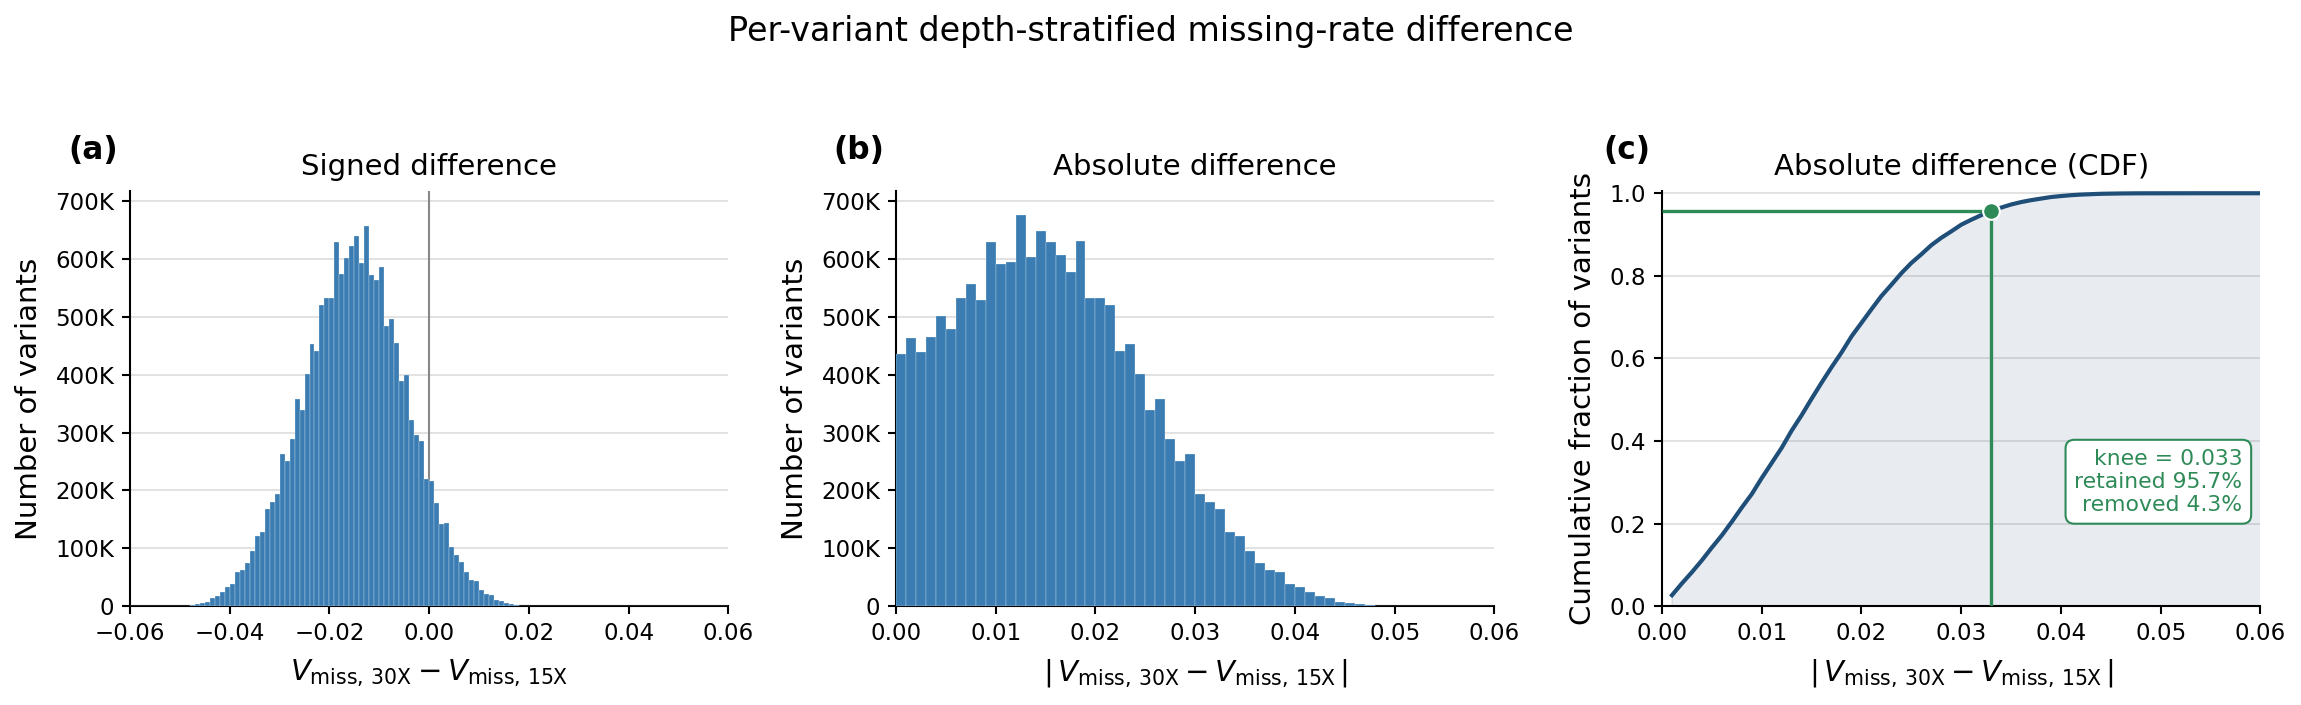

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator
from kneed import KneeLocator   # modified build in env cteph_geno_pro (supports weight_x / weight_y)

# =====================================================================
# Distribution of VMISS_30X - VMISS_15X over ALL variants.
#   (a) signed difference histogram
#   (b) absolute difference histogram      [shares y-range with (a)]
#   (c) absolute difference cumulative CDF  + kneedle knee/threshold
# Streamed in chunks (only the 2 needed columns, float32) so the
# ~266 MB / millions-of-rows file never lands fully in memory.
# =====================================================================

# Kneedle parameters (weights selectable later).
KNEE_S = 1.0
KNEE_WEIGHT_X = 1.0
KNEE_WEIGHT_Y = 2.0

if 'variant_metrics_path' not in globals() or variant_metrics_path is None:
    _vsrc = WORK_DIR / 'variant_metrics.txt.gz'
    if not _vsrc.exists():
        raise FileNotFoundError('variant_metrics_path missing. Run Cell 1 first.')
else:
    _vsrc = variant_metrics_path

NEEDED = ['VMISS_15X', 'VMISS_30X']

# Confirm the columns exist before streaming the whole file.
_head = pd.read_csv(_vsrc, sep='\t', nrows=0)
_missing = [c for c in NEEDED if c not in _head.columns]
if _missing:
    raise ValueError(
        f'Columns {_missing} not found in {Path(_vsrc).name}. '
        'Re-run Cell 1 with FORCE_RECALC=True to regenerate with the VMISS columns.'
    )

# Fixed bin edges (bounded ranges -> safe for streaming). Width 0.001.
edges_signed = np.linspace(-1.0, 1.0, 2001)   # signed diff in [-1, 1]
edges_abs = np.linspace(0.0, 1.0, 1001)        # |diff| in [0, 1]
hist_signed = np.zeros(len(edges_signed) - 1, dtype=np.int64)
hist_abs = np.zeros(len(edges_abs) - 1, dtype=np.int64)

CHUNK = 500_000
n_total = n_valid = 0
sum_signed = sum_abs = 0.0
min_signed, max_signed, max_abs = np.inf, -np.inf, 0.0

for chunk in pd.read_csv(
    _vsrc, sep='\t', usecols=NEEDED, chunksize=CHUNK, compression='infer',
    dtype={'VMISS_15X': 'float32', 'VMISS_30X': 'float32'},
):
    signed = (chunk['VMISS_30X'] - chunk['VMISS_15X']).to_numpy(dtype=np.float64)
    n_total += signed.size
    signed = signed[np.isfinite(signed)]      # drop variants where a stratum had no samples
    n_valid += signed.size
    if not signed.size:
        continue
    absd = np.abs(signed)
    sum_signed += float(signed.sum())
    sum_abs += float(absd.sum())
    min_signed = min(min_signed, float(signed.min()))
    max_signed = max(max_signed, float(signed.max()))
    max_abs = max(max_abs, float(absd.max()))
    hist_signed += np.histogram(signed, bins=edges_signed)[0]
    hist_abs += np.histogram(absd, bins=edges_abs)[0]

if n_valid == 0:
    raise ValueError(
        'No variants have finite VMISS_15X and VMISS_30X simultaneously. '
        'Check that Cell 1 produced both depth strata (non-empty 15X/30X keep lists).'
    )

mean_signed = sum_signed / n_valid
mean_abs = sum_abs / n_valid

# CDF of |diff| from the accumulated histogram.
cdf_abs = np.cumsum(hist_abs) / n_valid            # P(|diff| <= right edge)
cdf_x = edges_abs[1:]
quantiles = {q: float(cdf_x[np.searchsorted(cdf_abs, q, side='left')]) for q in (0.95, 0.99)}

# X-range focused on the populated region (rounded to 0.01, with headroom).
abs_hi = min(1.0, max(0.01, np.ceil(max_abs / 0.01) * 0.01))
sign_hi = min(1.0, max(0.01, np.ceil(max(abs(min_signed), abs(max_signed)) / 0.01) * 0.01))

# --- Kneedle knee of the |diff| CDF (concave, increasing) ---
# Restrict to the populated range so the long flat tail (CDF==1) does not
# dominate the [0,1] normalisation and bias the knee.
_km = cdf_x <= abs_hi
knee_thr = knee_cdf = None
if int(_km.sum()) >= 2:
    try:
        knee_locator = KneeLocator(
            cdf_x[_km], cdf_abs[_km], S=KNEE_S, curve='concave', direction='increasing',
            weight_x=KNEE_WEIGHT_X, weight_y=KNEE_WEIGHT_Y,
        )
        knee_thr = knee_locator.knee                  # threshold on |diff|
        knee_cdf = knee_locator.knee_y                # CDF value at the knee
    except Exception as _e:
        print(f'[warn] KneeLocator failed ({_e}); no knee will be drawn.')

if knee_thr is not None:
    retained_pct = 100.0 * float(knee_cdf)        # |diff| <= knee  -> kept
    removed_pct = 100.0 - retained_pct            # |diff| >  knee  -> removed
else:
    retained_pct = removed_pct = np.nan
    print('[warn] kneedle did not return a knee; downstream export cell will raise until one is found.')

print(f'variants total            : {n_total:,}')
print(f'variants with valid diff  : {n_valid:,}  (NaN dropped: {n_total - n_valid:,})')
print(f'signed diff  mean         : {mean_signed:.4g}   range [{min_signed:.4g}, {max_signed:.4g}]')
print(f'abs    diff  mean / max   : {mean_abs:.4g} / {max_abs:.4g}')
print(f'abs    diff  95th / 99th  : {quantiles[0.95]:.4g} / {quantiles[0.99]:.4g}')
print(f'kneedle (S={KNEE_S}, wx={KNEE_WEIGHT_X}, wy={KNEE_WEIGHT_Y}) -> '
      f'knee |diff| = {knee_thr}  |  retained {retained_pct:.2f}% / removed {removed_pct:.2f}%')

# =====================================================================
# Publication-grade figure (3 panels). White bg, linear y, clean axes.
# =====================================================================
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'axes.linewidth': 1.0, 'figure.dpi': 150,
    'text.color': 'black', 'axes.labelcolor': 'black', 'axes.edgecolor': 'black',
    'xtick.color': 'black', 'ytick.color': 'black',
})

BAR_COLOR, LINE_COLOR, KNEE_COLOR = '#3B7DB3', '#1F4E79', '#2E8B57'
cnt_fmt = FuncFormatter(lambda v, _: '0' if v == 0 else (f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'))

# Shared y-range for the two histogram panels.
cnt_max = max(hist_signed.max(), hist_abs.max()) * 1.06

ctr_s = 0.5 * (edges_signed[:-1] + edges_signed[1:])
ctr_a = 0.5 * (edges_abs[:-1] + edges_abs[1:])

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))
ax_s, ax_a, ax_c = axes

def _style(ax, grid_axis='y'):
    ax.set_axisbelow(True)
    if grid_axis:
        getattr(ax, f'{grid_axis}axis').grid(True, color='#DDDDDD', linewidth=0.8, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.0)

# --- (a) signed difference histogram ---
ax_s.bar(ctr_s, hist_signed, width=np.diff(edges_signed), align='center',
         color=BAR_COLOR, edgecolor='white', linewidth=0.12, zorder=3)
ax_s.axvline(0.0, color='#888888', linewidth=1.0, zorder=2)
ax_s.set_xlim(-sign_hi, sign_hi)
ax_s.set_ylim(0, cnt_max)
ax_s.xaxis.set_major_locator(MultipleLocator(0.02))
ax_s.yaxis.set_major_formatter(cnt_fmt)
ax_s.set_xlabel(r'$V_{\mathrm{miss,\,30X}} - V_{\mathrm{miss,\,15X}}$', labelpad=6)
ax_s.set_ylabel('Number of variants', labelpad=6)
ax_s.set_title('Signed difference', pad=8)
_style(ax_s)

# --- (b) absolute difference histogram (shared y-range with a) ---
ax_a.bar(ctr_a, hist_abs, width=np.diff(edges_abs), align='center',
         color=BAR_COLOR, edgecolor='white', linewidth=0.12, zorder=3)
ax_a.set_xlim(0, abs_hi)
ax_a.set_ylim(0, cnt_max)
ax_a.xaxis.set_major_locator(MultipleLocator(0.01))
ax_a.yaxis.set_major_formatter(cnt_fmt)
ax_a.set_xlabel(r'$|\,V_{\mathrm{miss,\,30X}} - V_{\mathrm{miss,\,15X}}\,|$', labelpad=6)
ax_a.set_ylabel('Number of variants', labelpad=6)
ax_a.set_title('Absolute difference', pad=8)
_style(ax_a)

# --- (c) absolute difference CDF + kneedle knee ---
ax_c.plot(cdf_x, cdf_abs, color=LINE_COLOR, linewidth=2.0, zorder=4)
ax_c.fill_between(cdf_x, cdf_abs, color=LINE_COLOR, alpha=0.10, zorder=1)

# Knee marker + guide lines + annotation (the only threshold shown)
if knee_thr is not None:
    ax_c.vlines(knee_thr, 0, knee_cdf, color=KNEE_COLOR, linewidth=1.6, zorder=5)
    ax_c.hlines(knee_cdf, 0, knee_thr, color=KNEE_COLOR, linewidth=1.6, zorder=5)
    ax_c.plot([knee_thr], [knee_cdf], 'o', color=KNEE_COLOR, markersize=8,
              markeredgecolor='white', markeredgewidth=1.0, zorder=6)
    ax_c.text(0.97, 0.30,
              (f'knee = {knee_thr:.3f}\n'
               f'retained {retained_pct:.1f}%\n'
               f'removed {removed_pct:.1f}%'),
              transform=ax_c.transAxes, ha='right', va='center', fontsize=10.5, color=KNEE_COLOR,
              bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=KNEE_COLOR, linewidth=1.0))

ax_c.set_xlim(0, abs_hi)
ax_c.set_ylim(0, 1.005)
ax_c.xaxis.set_major_locator(MultipleLocator(0.01))
ax_c.yaxis.set_major_locator(MultipleLocator(0.2))
ax_c.set_xlabel(r'$|\,V_{\mathrm{miss,\,30X}} - V_{\mathrm{miss,\,15X}}\,|$', labelpad=6)
ax_c.set_ylabel('Cumulative fraction of variants', labelpad=6)
ax_c.set_title('Absolute difference (CDF)', pad=8)
_style(ax_c)

# Panel letters (a)/(b)/(c)
for ax, letter in zip(axes, 'abc'):
    ax.text(-0.02, 1.06, f'({letter})', transform=ax.transAxes,
            fontsize=15, fontweight='bold', ha='right', va='bottom')

fig.suptitle('Per-variant depth-stratified missing-rate difference', fontsize=16, y=1.04)
fig.tight_layout()
plt.show()


## Step 3 · Export — variants to exclude at the chosen threshold

Writes the IDs of variants with `|VMISS_30X − VMISS_15X| > knee_thr` (one `VariantID` per line, no header → PLINK2 `--exclude`) to `results/02_vmiss_depthdiff_knee/`.


In [4]:
# =====================================================================
# Export variant IDs to REMOVE at the chosen threshold (kneedle knee).
#   remove if  |VMISS_30X - VMISS_15X| > knee_thr
# One VariantID per line, no header  ->  PLINK2 --exclude compatible.
# Streamed in chunks to keep memory low. Depends on the previous cell
# (knee_thr, _vsrc, NEEDED, CHUNK, WORK_DIR).
# =====================================================================
if 'knee_thr' not in globals() or knee_thr is None:
    raise RuntimeError('knee_thr is missing/None. Run the CDF + kneedle cell first.')

ID_COL = 'VariantID'
_hcols = pd.read_csv(_vsrc, sep='\t', nrows=0).columns
if ID_COL not in _hcols:
    raise ValueError(f"'{ID_COL}' not found in {Path(_vsrc).name}; columns: {list(_hcols)}")

OUT_DIR_02 = WORK_DIR.parent / '02_vmiss_depthdiff_knee'
OUT_DIR_02.mkdir(parents=True, exist_ok=True)
REMOVE_FILE = OUT_DIR_02 / f'variants_vmiss_depthdiff_gt{knee_thr:.4f}.exclude.txt'

n_scanned = n_finite = n_removed = 0
with open(REMOVE_FILE, 'w') as fout:
    for chunk in pd.read_csv(
        _vsrc, sep='\t', usecols=[ID_COL] + NEEDED, chunksize=CHUNK, compression='infer',
        dtype={'VMISS_15X': 'float32', 'VMISS_30X': 'float32'},
    ):
        diff = (chunk['VMISS_30X'] - chunk['VMISS_15X']).abs().to_numpy()
        finite = np.isfinite(diff)
        mask = finite & (diff > knee_thr)               # large depth-dependent missingness -> drop
        n_scanned += len(chunk)
        n_finite += int(finite.sum())
        if mask.any():
            ids = chunk[ID_COL].to_numpy()[mask].astype(str)
            fout.write('\n'.join(ids) + '\n')
            n_removed += int(mask.sum())

if n_finite == 0:
    raise ValueError('No variants with valid depth-stratified missingness were found; nothing to export.')

# Sanity: the exported fraction should match the knee "removed%" from the previous cell.
pct_valid = 100.0 * n_removed / n_finite
pct_all = 100.0 * n_removed / n_scanned if n_scanned else float('nan')
print(f'threshold (knee)   : |VMISS_30X - VMISS_15X| > {knee_thr:.4f}')
print(f'variants scanned   : {n_scanned:,}')
print(f'variants w/ valid  : {n_finite:,}')
print(f'variants to REMOVE : {n_removed:,}  ({pct_valid:.2f}% of valid, {pct_all:.2f}% of all)')
print(f'Exclude file       : {REMOVE_FILE}')


threshold (knee)   : |VMISS_30X - VMISS_15X| > 0.0330
variants scanned   : 16,200,624
variants w/ valid  : 16,200,624
variants to REMOVE : 691,786  (4.27% of valid, 4.27% of all)
Exclude file       : /LARGE0/gr10478/b37974/Pulmonary_Hypertension/cteph_agp3k.v6/tuning.rv/pre_check/results/02_vmiss_depthdiff_knee/variants_vmiss_depthdiff_gt0.0330.exclude.txt
